# 02 Weighted EDA

All statistics are **PATWT-weighted** — each record's contribution is scaled by its survey weight so that results represent the national ED visit population, not the raw sample counts.

Prerequisite: run `01_data_prep.ipynb` first.

**Sections:**
1. Weighted wait time distribution
2. Temporal patterns (hour, day, month)
3. Triage urgency (IMMEDR)
4. Geography (REGION, MSA)
5. Demographics (age, sex)
6. Operational feature prevalence — setup for bottleneck analysis

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
DATA = Path('../data')

df = pd.read_csv(DATA / 'eda_df.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'PATWT missing: {df["PATWT"].isna().sum()}')
print(f'Years: {sorted(df["YEAR"].dropna().unique().astype(int).tolist())}')

# ── Label maps ────────────────────────────────────────────────────────────────
REGION_LABELS  = {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}
MSA_LABELS     = {1: 'Urban (MSA)', 2: 'Rural (non-MSA)'}
IMMEDR_LABELS  = {
    0: 'Not recorded',
    1: 'Immediate',
    2: 'Emergent',
    3: 'Urgent',
    4: 'Semi-urgent',
    5: 'Non-urgent',
    7: 'No triage',
}
VDAYR_LABELS   = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
SEX_LABELS     = {1: 'Male', 2: 'Female'}

# ── Weighted mean helper ──────────────────────────────────────────────────────
def wmean(values, weights):
    mask = values.notna() & weights.notna()
    return np.average(values[mask], weights=weights[mask])

def weighted_group_stats(df, groupby_col, value_col='WAITTIME', weight_col='PATWT', label_map=None):
    """Return PATWT-weighted mean/median wait and weighted visit share per group."""
    rows = []
    total_w = df[weight_col].sum()
    for grp, sub in df.groupby(groupby_col, dropna=True):
        v = sub[value_col].dropna()
        w = sub.loc[v.index, weight_col]
        if len(v) < 10:
            continue
        rows.append({
            groupby_col: grp,
            'label': label_map.get(grp, str(grp)) if label_map else str(grp),
            'n_records': len(sub),
            'weighted_share_pct': sub[weight_col].sum() / total_w * 100,
            'weighted_mean_wait': np.average(v, weights=w),
        })
    return pd.DataFrame(rows)

OVERALL_WMEAN = wmean(df['WAITTIME'], df['PATWT'])
print(f'\nOverall PATWT-weighted mean wait time: {OVERALL_WMEAN:.1f} min')
print(f'Overall unweighted mean wait time:     {df["WAITTIME"].mean():.1f} min')

Loaded: 91,811 rows × 38 cols
PATWT missing: 0
Years: [2015, 2016, 2017, 2018, 2021, 2022]

Overall PATWT-weighted mean wait time: 34.7 min
Overall unweighted mean wait time:     34.1 min


## 1. Weighted wait time distribution

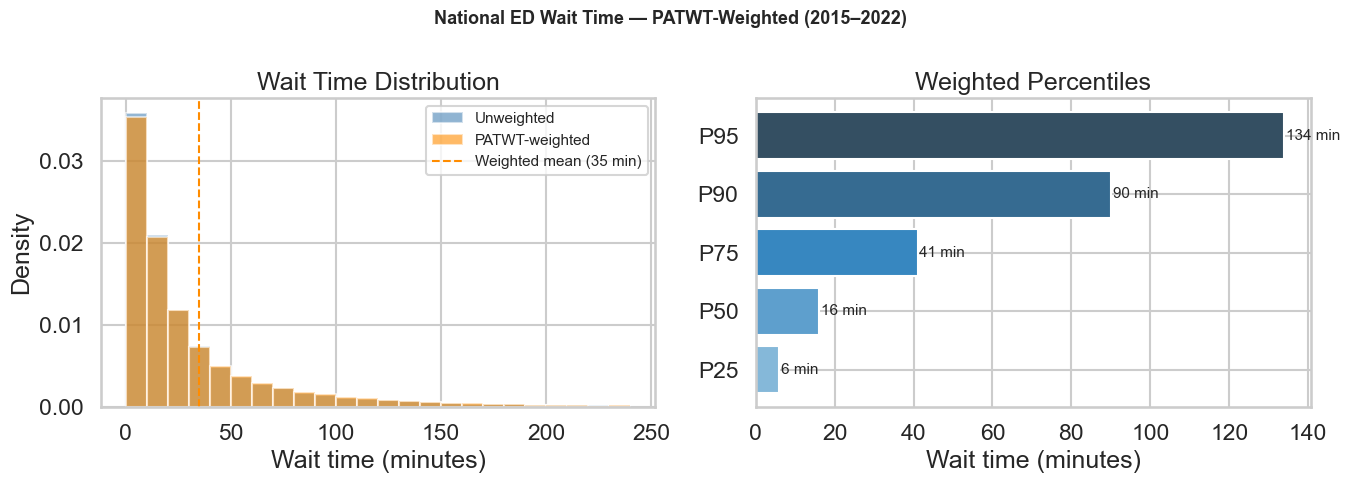

Weighted percentiles: {'P25': '6', 'P50': '16', 'P75': '41', 'P90': '90', 'P95': '134'}


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unweighted vs weighted histogram
bins = np.arange(0, 241, 10)
axes[0].hist(df['WAITTIME'], bins=bins, density=True, alpha=0.6, label='Unweighted', color='steelblue')
axes[0].hist(df['WAITTIME'], bins=bins, density=True, alpha=0.6,
             weights=df['PATWT'], label='PATWT-weighted', color='darkorange')
axes[0].axvline(OVERALL_WMEAN, color='darkorange', linestyle='--', linewidth=1.5,
                label=f'Weighted mean ({OVERALL_WMEAN:.0f} min)')
axes[0].set_xlabel('Wait time (minutes)')
axes[0].set_ylabel('Density')
axes[0].set_title('Wait Time Distribution')
axes[0].legend(fontsize=11)

# Percentiles (weighted)
sorted_idx = df['WAITTIME'].argsort()
vals_sorted = df['WAITTIME'].iloc[sorted_idx].values
wts_sorted  = df['PATWT'].iloc[sorted_idx].values
cum_wt = np.cumsum(wts_sorted) / wts_sorted.sum()
pcts = [25, 50, 75, 90, 95]
pct_vals = [vals_sorted[np.searchsorted(cum_wt, p/100)] for p in pcts]
axes[1].barh([f'P{p}' for p in pcts], pct_vals, color=sns.color_palette('Blues_d', len(pcts)))
axes[1].set_xlabel('Wait time (minutes)')
axes[1].set_title('Weighted Percentiles')
for i, v in enumerate(pct_vals):
    axes[1].text(v + 0.5, i, f'{v:.0f} min', va='center', fontsize=11)

plt.suptitle('National ED Wait Time — PATWT-Weighted (2015–2022)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA.parent / 'appengine/assets/waittime_distribution_weighted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Weighted percentiles:', dict(zip([f'P{p}' for p in pcts], [f'{v:.0f}' for v in pct_vals])))

## 2. Temporal patterns

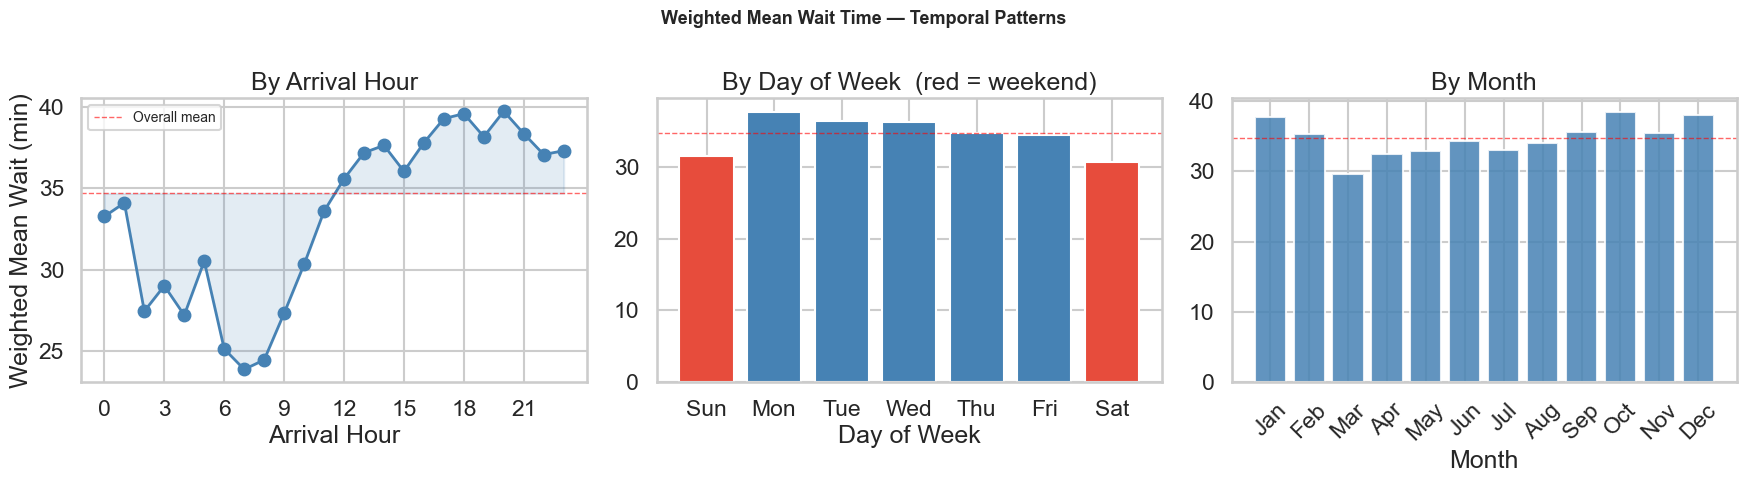

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By hour
hour_stats = weighted_group_stats(df, 'ARRIVAL_HOUR')
hour_stats = hour_stats.sort_values('ARRIVAL_HOUR')
axes[0].plot(hour_stats['ARRIVAL_HOUR'], hour_stats['weighted_mean_wait'],
             marker='o', color='steelblue', linewidth=2)
axes[0].axhline(OVERALL_WMEAN, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Overall mean')
axes[0].fill_between(hour_stats['ARRIVAL_HOUR'], hour_stats['weighted_mean_wait'],
                     OVERALL_WMEAN, alpha=0.15, color='steelblue')
axes[0].set_xlabel('Arrival Hour')
axes[0].set_ylabel('Weighted Mean Wait (min)')
axes[0].set_title('By Arrival Hour')
axes[0].legend(fontsize=10)
axes[0].set_xticks(range(0, 24, 3))

# By day of week
day_stats = weighted_group_stats(df, 'VDAYR', label_map=VDAYR_LABELS)
day_stats = day_stats.sort_values('VDAYR')
colors = ['#e74c3c' if d in [1, 7] else 'steelblue' for d in day_stats['VDAYR']]
axes[1].bar(day_stats['label'], day_stats['weighted_mean_wait'], color=colors)
axes[1].axhline(OVERALL_WMEAN, color='red', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_xlabel('Day of Week')
axes[1].set_title('By Day of Week  (red = weekend)')
axes[1].set_ylabel('')

# By month
month_stats = weighted_group_stats(df, 'VMONTH')
month_stats = month_stats.sort_values('VMONTH')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(month_stats['VMONTH'].astype(int) - 1,
            month_stats['weighted_mean_wait'], color='steelblue', alpha=0.85)
axes[2].axhline(OVERALL_WMEAN, color='red', linestyle='--', linewidth=1, alpha=0.6)
axes[2].set_xticks(range(12))
axes[2].set_xticklabels(month_labels, rotation=45)
axes[2].set_xlabel('Month')
axes[2].set_title('By Month')

plt.suptitle('Weighted Mean Wait Time — Temporal Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA.parent / 'appengine/assets/waittime_temporal_weighted.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Triage urgency (IMMEDR)

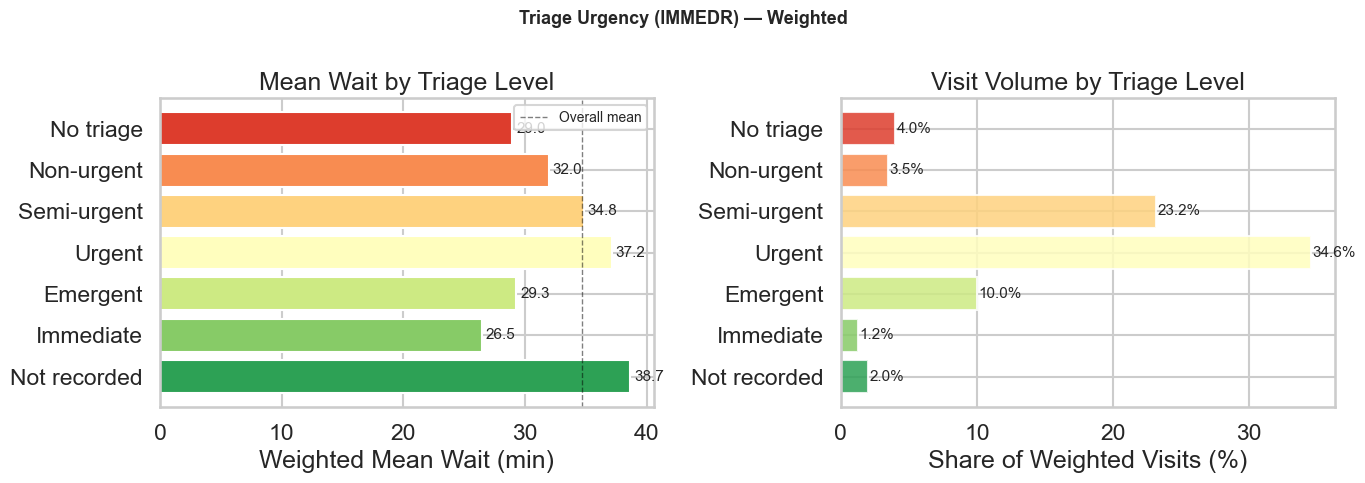

       label  n_records  weighted_share_pct  weighted_mean_wait
Not recorded       1973            2.016397           38.654010
   Immediate        909            1.244575           26.460811
    Emergent       8719            9.973663           29.297598
      Urgent      32276           34.553731           37.152301
 Semi-urgent      21429           23.163327           34.843865
  Non-urgent       3458            3.471410           31.974354
   No triage       4008            4.003589           28.969048


In [4]:
triage_stats = weighted_group_stats(df, 'IMMEDR', label_map=IMMEDR_LABELS)
triage_stats = triage_stats.sort_values('IMMEDR')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette('RdYlGn_r', len(triage_stats))
axes[0].barh(triage_stats['label'], triage_stats['weighted_mean_wait'], color=palette)
axes[0].axvline(OVERALL_WMEAN, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Overall mean')
axes[0].set_xlabel('Weighted Mean Wait (min)')
axes[0].set_title('Mean Wait by Triage Level')
axes[0].legend(fontsize=10)
for i, row in triage_stats.reset_index(drop=True).iterrows():
    axes[0].text(row['weighted_mean_wait'] + 0.3, i, f"{row['weighted_mean_wait']:.1f}", va='center', fontsize=11)

axes[1].barh(triage_stats['label'], triage_stats['weighted_share_pct'], color=palette, alpha=0.85)
axes[1].set_xlabel('Share of Weighted Visits (%)')
axes[1].set_title('Visit Volume by Triage Level')
for i, row in triage_stats.reset_index(drop=True).iterrows():
    axes[1].text(row['weighted_share_pct'] + 0.1, i, f"{row['weighted_share_pct']:.1f}%", va='center', fontsize=11)

plt.suptitle('Triage Urgency (IMMEDR) — Weighted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA.parent / 'appengine/assets/waittime_by_triage_weighted.png', dpi=150, bbox_inches='tight')
plt.show()
print(triage_stats[['label','n_records','weighted_share_pct','weighted_mean_wait']].to_string(index=False))

## 4. Geography — Region and MSA

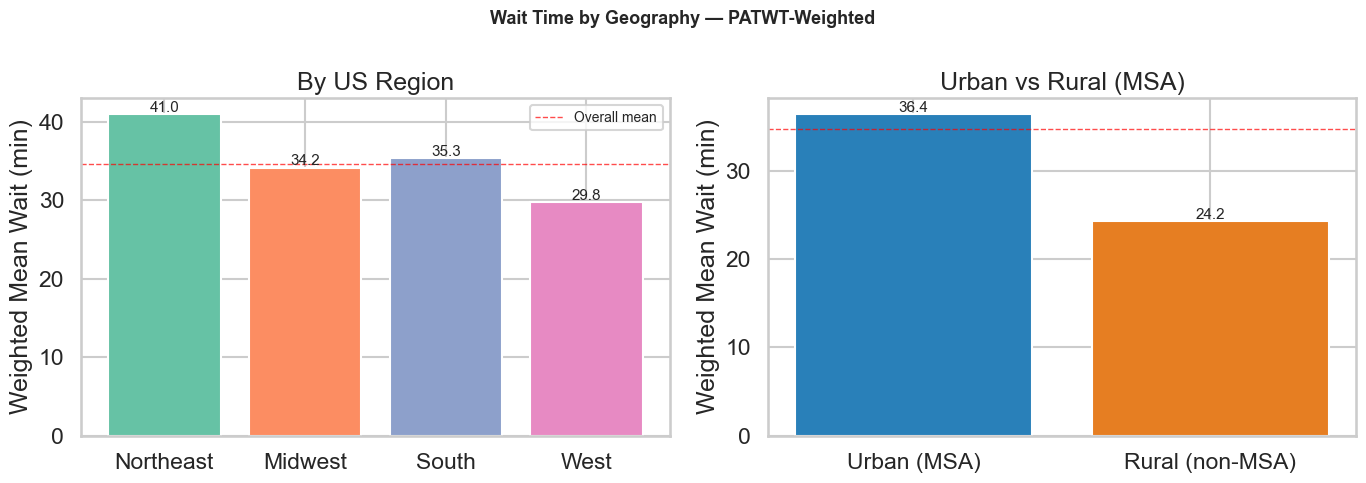

Region stats:
    label  weighted_share_pct  weighted_mean_wait
Northeast           14.886272           40.967530
  Midwest           23.064197           34.151094
    South           40.222854           35.349931
     West           21.826677           29.784326

MSA stats:
          label  weighted_share_pct  weighted_mean_wait
    Urban (MSA)            86.14399           36.375051
Rural (non-MSA)            13.85601           24.249212


In [5]:
region_stats = weighted_group_stats(df, 'REGION', label_map=REGION_LABELS)
msa_stats    = weighted_group_stats(df, 'MSA',    label_map=MSA_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r_palette = sns.color_palette('Set2', len(region_stats))
axes[0].bar(region_stats['label'], region_stats['weighted_mean_wait'], color=r_palette)
axes[0].axhline(OVERALL_WMEAN, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Overall mean')
axes[0].set_ylabel('Weighted Mean Wait (min)')
axes[0].set_title('By US Region')
axes[0].legend(fontsize=10)
for i, row in region_stats.reset_index(drop=True).iterrows():
    axes[0].text(i, row['weighted_mean_wait'] + 0.3, f"{row['weighted_mean_wait']:.1f}",
                 ha='center', fontsize=11)

axes[1].bar(msa_stats['label'], msa_stats['weighted_mean_wait'],
            color=['#2980b9', '#e67e22'])
axes[1].axhline(OVERALL_WMEAN, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_ylabel('Weighted Mean Wait (min)')
axes[1].set_title('Urban vs Rural (MSA)')
for i, row in msa_stats.reset_index(drop=True).iterrows():
    axes[1].text(i, row['weighted_mean_wait'] + 0.3, f"{row['weighted_mean_wait']:.1f}",
                 ha='center', fontsize=11)

plt.suptitle('Wait Time by Geography — PATWT-Weighted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA.parent / 'appengine/assets/waittime_by_region_weighted.png', dpi=150, bbox_inches='tight')
plt.show()

print('Region stats:')
print(region_stats[['label','weighted_share_pct','weighted_mean_wait']].to_string(index=False))
print('\nMSA stats:')
print(msa_stats[['label','weighted_share_pct','weighted_mean_wait']].to_string(index=False))

## 5. Demographics

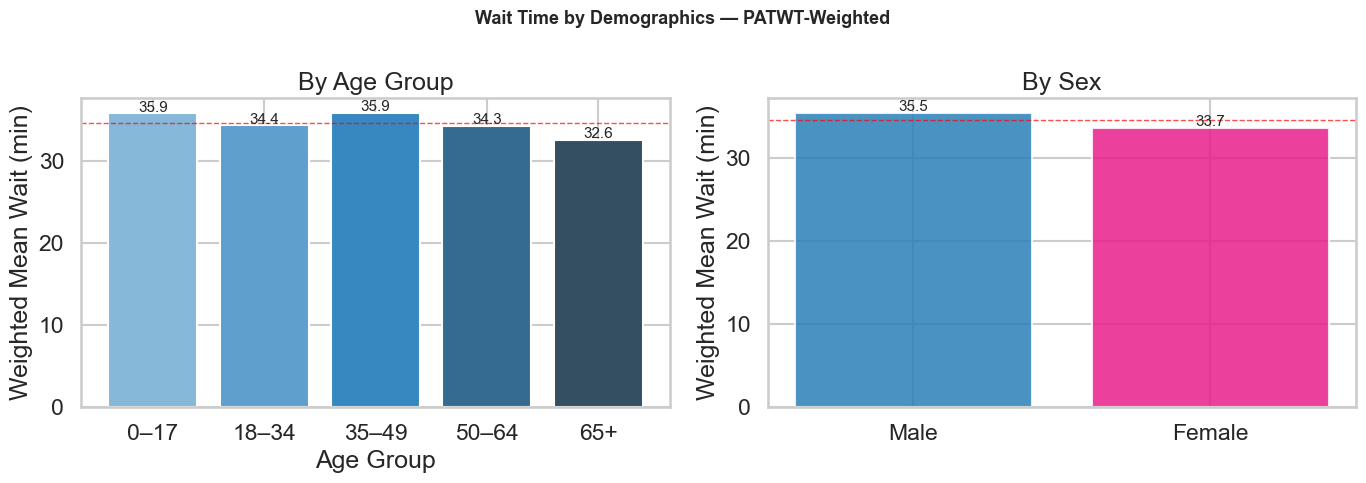

In [6]:
# Age bins
df['AGE_BIN'] = pd.cut(df['AGE'], bins=[0, 17, 34, 49, 64, 120],
                        labels=['0–17', '18–34', '35–49', '50–64', '65+'])
age_stats = weighted_group_stats(df, 'AGE_BIN')
sex_stats = weighted_group_stats(df, 'SEX', label_map=SEX_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_stats['label'], age_stats['weighted_mean_wait'],
            color=sns.color_palette('Blues_d', len(age_stats)))
axes[0].axhline(OVERALL_WMEAN, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Weighted Mean Wait (min)')
axes[0].set_title('By Age Group')
for i, row in age_stats.reset_index(drop=True).iterrows():
    axes[0].text(i, row['weighted_mean_wait'] + 0.2, f"{row['weighted_mean_wait']:.1f}",
                 ha='center', fontsize=11)

axes[1].bar(sex_stats['label'], sex_stats['weighted_mean_wait'],
            color=['#2980b9', '#e91e8c'], alpha=0.85)
axes[1].axhline(OVERALL_WMEAN, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_ylabel('Weighted Mean Wait (min)')
axes[1].set_title('By Sex')
for i, row in sex_stats.reset_index(drop=True).iterrows():
    axes[1].text(i, row['weighted_mean_wait'] + 0.2, f"{row['weighted_mean_wait']:.1f}",
                 ha='center', fontsize=11)

plt.suptitle('Wait Time by Demographics — PATWT-Weighted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Operational feature prevalence

For each operational flag, we compute: (a) what share of visits nationally occur with this feature present, and (b) how much higher the mean wait time is when it's present vs. absent. This sets up the bottleneck analysis in `03_bottleneck_analysis.ipynb`.

In [7]:
operational_flags = [
    ('FASTTRAK',  'Fast-track / urgent care ESA'),
    ('OBSCLIN',   'Observation / clinical decision unit'),
    ('BOARD',     'Patient boarded in ED'),
    ('BEDREG',    'Bed request required (bed czar/registry)'),
    ('IMBED',     'Immediate bedding used'),
    ('BEDCZAR',   'Bed czar / bed management present'),
    ('ANYIMAGE',  'Any imaging ordered'),
    ('MRI',       'MRI ordered'),
    ('XRAY',      'X-ray ordered'),
    ('CTCONTRAST','CT with contrast ordered'),
]

summary_rows = []
total_w = df['PATWT'].sum()

for col, label in operational_flags:
    if col not in df.columns:
        continue
    present = df[col] == 1
    absent  = df[col] == 2  # NHAMCS: 1=Yes, 2=No

    # Some cols use 0/1 instead of 1/2 — detect and normalise
    vals = df[col].dropna().unique()
    if set(vals).issubset({0, 1, 0.0, 1.0}):
        present = df[col] == 1
        absent  = df[col] == 0

    pres_sub = df[present]
    abs_sub  = df[absent]

    if len(pres_sub) < 10 or len(abs_sub) < 10:
        continue

    pres_wmean = wmean(pres_sub['WAITTIME'], pres_sub['PATWT'])
    abs_wmean  = wmean(abs_sub['WAITTIME'],  abs_sub['PATWT'])
    pres_share = pres_sub['PATWT'].sum() / total_w * 100

    summary_rows.append({
        'Feature': label,
        'Code':    col,
        'Present_Share_%': round(pres_share, 1),
        'Wait_If_Present': round(pres_wmean, 1),
        'Wait_If_Absent':  round(abs_wmean,  1),
        'Delta_min':       round(pres_wmean - abs_wmean, 1),
    })

ops_df = pd.DataFrame(summary_rows).sort_values('Delta_min', ascending=False)
print('Operational feature summary (PATWT-weighted):')
display(ops_df.reset_index(drop=True))

Operational feature summary (PATWT-weighted):


,Feature,Code,Present_Share_%,Wait_If_Present,Wait_If_Absent,Delta_min
0,Patient boarded in ED,BOARD,77.3,35.6,27.9,7.7
1,CT with contrast ordered,CTCONTRAST,6.3,39.0,31.5,7.5
2,Bed czar / bed management present,BEDCZAR,73.0,36.2,29.5,6.8
3,Observation / clinical decision unit,OBSCLIN,43.4,37.4,32.3,5.0
4,Fast-track / urgent care ESA,FASTTRAK,59.2,34.7,33.1,1.6
5,Bed request required (bed czar/registry),BEDREG,86.7,34.4,33.6,0.8
6,Any imaging ordered,ANYIMAGE,52.6,35.0,34.4,0.6
7,MRI ordered,MRI,1.2,34.7,34.7,0.0
8,X-ray ordered,XRAY,36.7,34.0,35.1,-1.0
9,Immediate bedding used,IMBED,70.0,33.6,35.5,-1.9


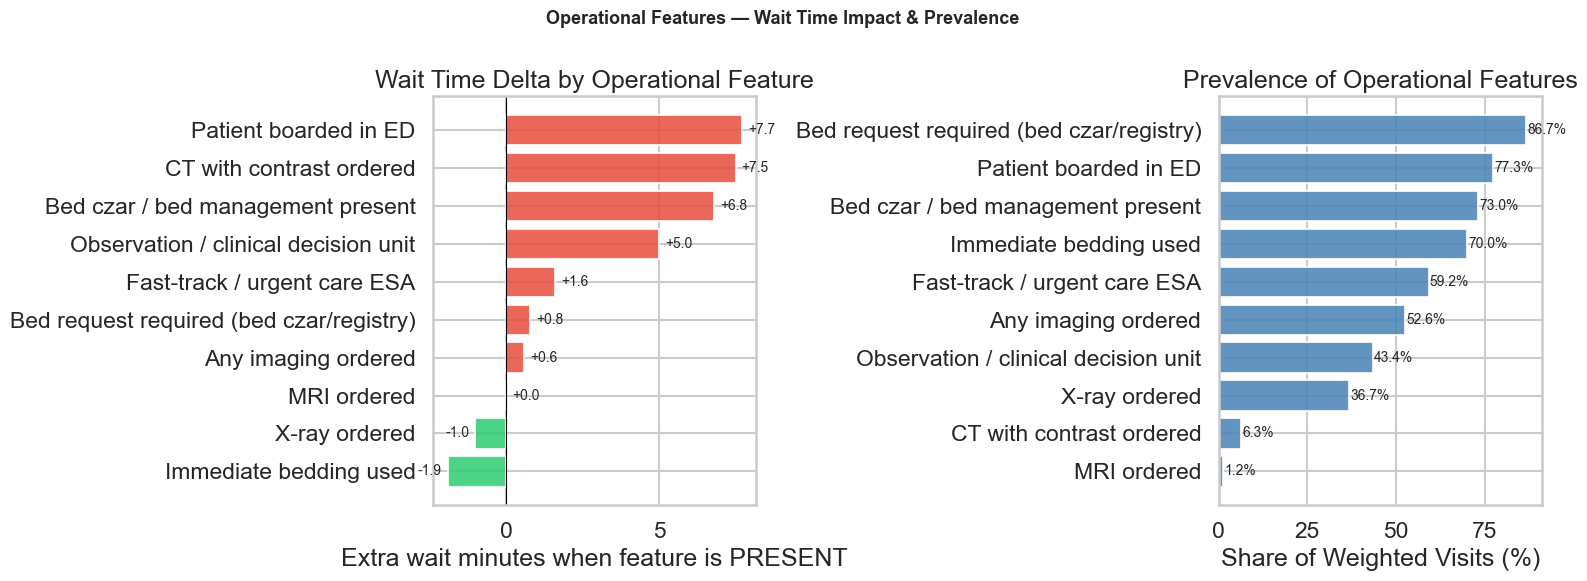

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ops_plot = ops_df.sort_values('Delta_min')

colors = ['#e74c3c' if d > 0 else '#2ecc71' for d in ops_plot['Delta_min']]
axes[0].barh(ops_plot['Feature'], ops_plot['Delta_min'], color=colors, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Extra wait minutes when feature is PRESENT')
axes[0].set_title('Wait Time Delta by Operational Feature')
for i, (_, row) in enumerate(ops_plot.iterrows()):
    axes[0].text(row['Delta_min'] + (0.2 if row['Delta_min'] >= 0 else -0.2), i,
                 f"{row['Delta_min']:+.1f}", va='center', fontsize=10,
                 ha='left' if row['Delta_min'] >= 0 else 'right')

ops_share = ops_df.sort_values('Present_Share_%', ascending=True)
axes[1].barh(ops_share['Feature'], ops_share['Present_Share_%'],
             color='steelblue', alpha=0.85)
axes[1].set_xlabel('Share of Weighted Visits (%)')
axes[1].set_title('Prevalence of Operational Features')
for i, (_, row) in enumerate(ops_share.iterrows()):
    axes[1].text(row['Present_Share_%'] + 0.3, i, f"{row['Present_Share_%']:.1f}%",
                 va='center', fontsize=10)

plt.suptitle('Operational Features — Wait Time Impact & Prevalence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA.parent / 'appengine/assets/operational_features_weighted.png', dpi=150, bbox_inches='tight')
plt.show()